In [99]:
# ============================================================
# 2.1 DESCRIPCIÓN DEL DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar dataset original
df_raw = pd.read_csv("support2.csv")

print("=" * 60)
print("2.1 DESCRIPCIÓN DEL DATASET")
print("=" * 60)

print(f"Número de pacientes: {df_raw.shape[0]}")
print(f"Número de variables: {df_raw.shape[1]}")

print("\nPrimeras 5 observaciones:")
print(df_raw.head())

print("\nVariables disponibles:")
print(df_raw.columns.tolist())

print("\nTipos de datos:")
print(df_raw.dtypes)

print("\nInformación general:")
df_raw.info()

print("\nEstadísticas descriptivas:")
print(df_raw.describe().T.round(2))

print("\nVariable objetivo hospdead:")
print(df_raw["hospdead"].value_counts(dropna=False).sort_index())

2.1 DESCRIPCIÓN DEL DATASET
Número de pacientes: 9105
Número de variables: 47

Primeras 5 observaciones:
        age  death     sex  hospdead  slos  d.time            dzgroup  \
1  62.84998      0    male         0     5    2029        Lung Cancer   
2  60.33899      1  female         1     4       4          Cirrhosis   
3  52.74698      1  female         0    17      47          Cirrhosis   
4  42.38498      1  female         0     3     133        Lung Cancer   
5  79.88495      0  female         0    16    2029  ARF/MOSF w/Sepsis   

              dzclass  num.co   edu  ...      crea    sod        ph  glucose  \
1              Cancer       0  11.0  ...  1.199951  141.0  7.459961      NaN   
2  COPD/CHF/Cirrhosis       2  12.0  ...  5.500000  132.0  7.250000      NaN   
3  COPD/CHF/Cirrhosis       2  12.0  ...  2.000000  134.0  7.459961      NaN   
4              Cancer       2  11.0  ...  0.799927  139.0       NaN      NaN   
5            ARF/MOSF       1   NaN  ...  0.799927  143.

2.2 ANÁLISIS DE VALORES FALTANTES

Valores faltantes por variable:
         Faltantes  Porcentaje (%)
adlp          5641           61.95
urine         4862           53.40
glucose       4500           49.42
bun           4352           47.80
totmcst       3475           38.17
alb           3372           37.03
income        2982           32.75
adls          2867           31.49
bili          2601           28.57
pafi          2325           25.54
ph            2284           25.09
prg2m         1649           18.11
edu           1634           17.95
prg6m         1633           17.94
sfdm2         1400           15.38
totcst         888            9.75
wblc           212            2.33
charges        172            1.89
avtisst         82            0.90
crea            67            0.74
race            42            0.46
dnrday          30            0.33
dnr             30            0.33
scoma            1            0.01
sps              1            0.01
meanbp           1     

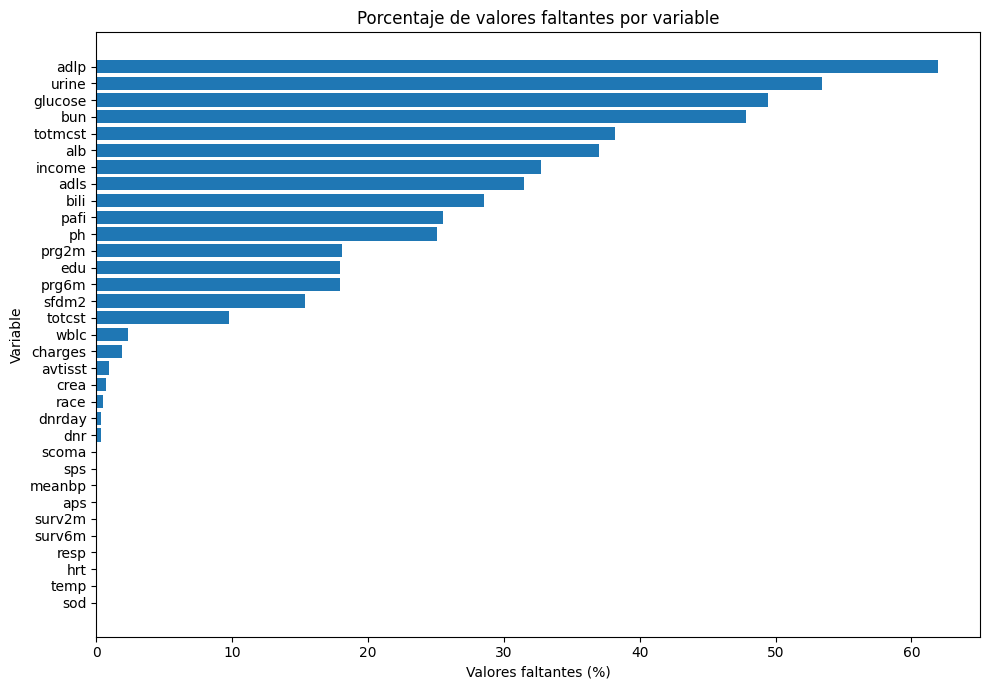

In [100]:
# ============================================================
# 2.2 ANÁLISIS DE VALORES FALTANTES
# ============================================================

print("=" * 60)
print("2.2 ANÁLISIS DE VALORES FALTANTES")
print("=" * 60)

missing = pd.DataFrame({
    "Faltantes": df_raw.isnull().sum(),
    "Porcentaje (%)": df_raw.isnull().mean() * 100
})

# Mostrar solo variables con datos faltantes
missing = missing[
    missing["Faltantes"] > 0
].sort_values(
    "Porcentaje (%)",
    ascending=False
)

missing["Porcentaje (%)"] = missing["Porcentaje (%)"].round(2)

print("\nValores faltantes por variable:")
print(missing)

print(
    "\nNúmero de variables con valores faltantes:",
    len(missing)
)

# Gráfico
plt.figure(figsize=(10, 7))

plt.barh(
    missing.index,
    missing["Porcentaje (%)"]
)

plt.xlabel("Valores faltantes (%)")
plt.ylabel("Variable")
plt.title("Porcentaje de valores faltantes por variable")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [101]:
# ============================================================
# 2.3 IDENTIFICACIÓN Y PREVENCIÓN DE DATA LEAKAGE
# ============================================================

print("=" * 60)
print("2.3 DATA LEAKAGE")
print("=" * 60)

leakage_cols = [
    "sps",
    "aps",
    "surv2m",
    "surv6m",
    "prg2m",
    "prg6m",
    "dnr",
    "dnrday"
]

tabla_leakage = pd.DataFrame({
    "Variable": leakage_cols,
    "Presente_en_dataset": [
        col in df_raw.columns
        for col in leakage_cols
    ]
})

print("\nVariables identificadas con riesgo de leakage:")
print(tabla_leakage)

# Crear copia para el resto del EDA
# El dataset original se conserva en df_raw
columnas_eliminar = [
    col for col in leakage_cols
    if col in df_raw.columns
]

df_eda = df_raw.drop(
    columns=columnas_eliminar
).copy()

print("\nDimensiones originales:")
print(df_raw.shape)

print("\nDimensiones después de excluir leakage:")
print(df_eda.shape)

print("\nVariables excluidas:")
print(columnas_eliminar)

2.3 DATA LEAKAGE

Variables identificadas con riesgo de leakage:
  Variable  Presente_en_dataset
0      sps                 True
1      aps                 True
2   surv2m                 True
3   surv6m                 True
4    prg2m                 True
5    prg6m                 True
6      dnr                 True
7   dnrday                 True

Dimensiones originales:
(9105, 47)

Dimensiones después de excluir leakage:
(9105, 39)

Variables excluidas:
['sps', 'aps', 'surv2m', 'surv6m', 'prg2m', 'prg6m', 'dnr', 'dnrday']


2.4 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO

Distribución de hospdead:
          Frecuencia  Porcentaje (%)
hospdead                            
0               6745           74.08
1               2360           25.92


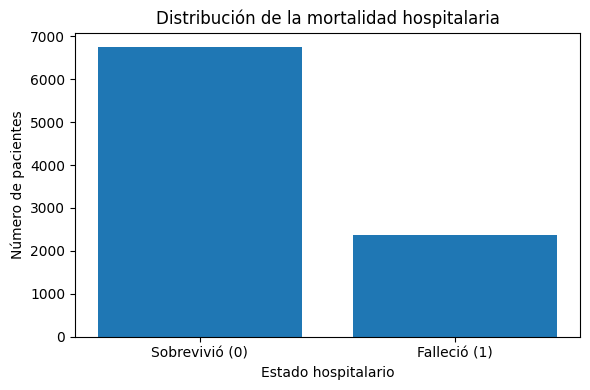

In [102]:
# ============================================================
# 2.4 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ============================================================

print("=" * 60)
print("2.4 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
print("=" * 60)

conteo = (
    df_eda["hospdead"]
    .value_counts()
    .sort_index()
)

porcentaje = (
    df_eda["hospdead"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

tabla_clases = pd.DataFrame({
    "Frecuencia": conteo,
    "Porcentaje (%)": porcentaje.round(2)
})

print("\nDistribución de hospdead:")
print(tabla_clases)

plt.figure(figsize=(6, 4))

plt.bar(
    ["Sobrevivió (0)", "Falleció (1)"],
    conteo.values
)

plt.xlabel("Estado hospitalario")
plt.ylabel("Número de pacientes")
plt.title("Distribución de la mortalidad hospitalaria")

plt.tight_layout()
plt.show()

2.5 VARIABLES FISIOLÓGICAS SEGÚN MORTALIDAD

Resumen fisiológico según mortalidad:
         meanbp                 wblc                  hrt                \
           mean median    std   mean median   std    mean median    std   
hospdead                                                                  
0         85.98   79.0  26.38  11.96   10.3  8.99   95.37   96.0  29.79   
1         80.45   73.0  30.75  13.43   11.7  9.92  102.25  108.0  35.66   

           resp  ...    ph glucose                  bun                \
           mean  ...   std    mean median    std   mean median    std   
hospdead         ...                                                    
0         23.21  ...  0.08  159.25  133.0  88.06  31.78   23.0  26.34   
1         23.67  ...  0.09  161.72  139.0  89.39  34.04   24.0  28.04   

            urine                   
             mean  median      std  
hospdead                            
0         2205.59  1975.0  1450.38  
1         2149.76  1937.0  

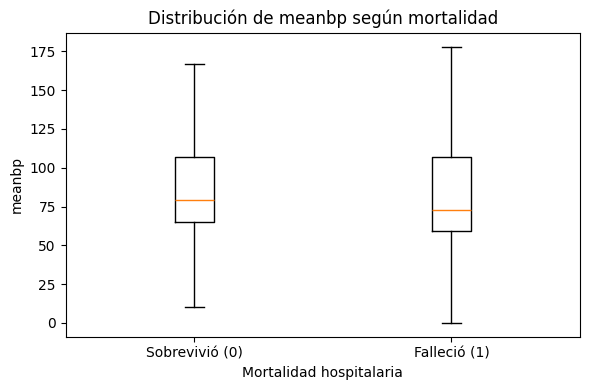

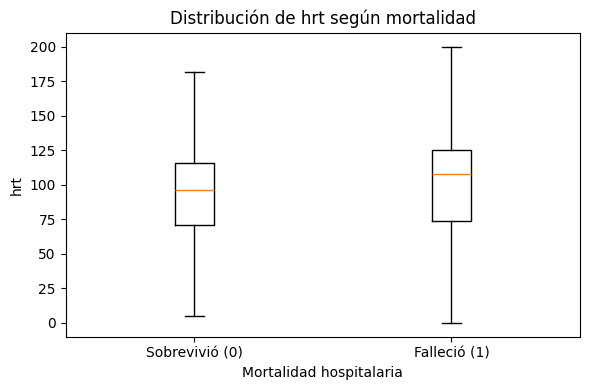

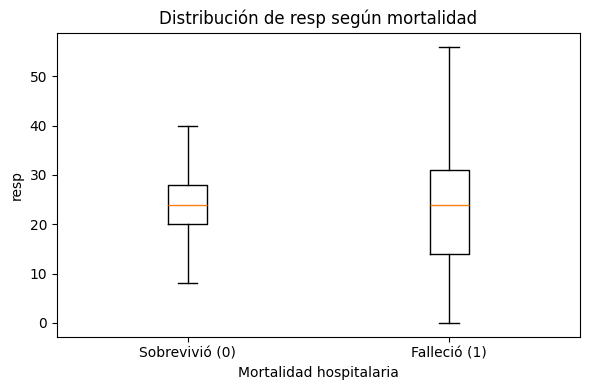

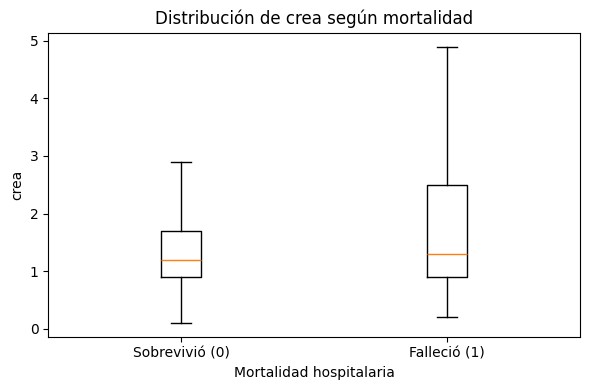

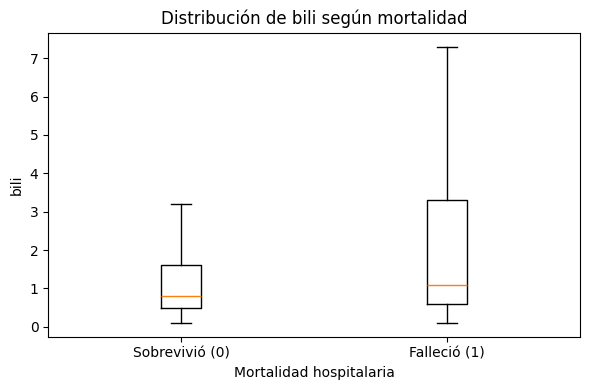

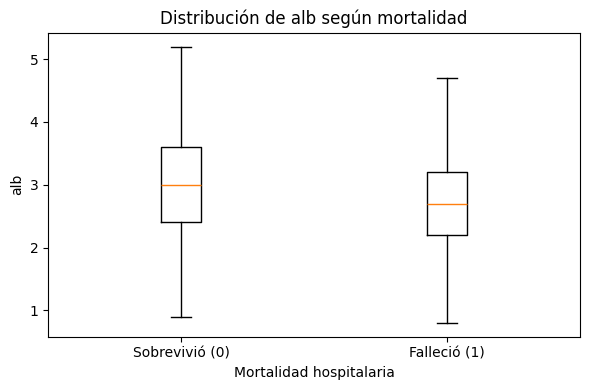

In [103]:
# ============================================================
# 2.5 VARIABLES FISIOLÓGICAS SEGÚN MORTALIDAD
# ============================================================

print("=" * 60)
print("2.5 VARIABLES FISIOLÓGICAS SEGÚN MORTALIDAD")
print("=" * 60)

fisiologicas = [
    "meanbp",
    "wblc",
    "hrt",
    "resp",
    "temp",
    "pafi",
    "alb",
    "bili",
    "crea",
    "sod",
    "ph",
    "glucose",
    "bun",
    "urine"
]

# Mantener solo las columnas que realmente existan
fisiologicas = [
    col for col in fisiologicas
    if col in df_eda.columns
]

# Media, mediana y desviación estándar según mortalidad
resumen_fisio = (
    df_eda
    .groupby("hospdead")[fisiologicas]
    .agg(["mean", "median", "std"])
)

print("\nResumen fisiológico según mortalidad:")
print(resumen_fisio.round(2))


# ------------------------------------------------------------
# BOXPLOTS DE VARIABLES REPRESENTATIVAS
# ------------------------------------------------------------

vars_boxplot = [
    "meanbp",
    "hrt",
    "resp",
    "crea",
    "bili",
    "alb"
]

for col in vars_boxplot:

    if col not in df_eda.columns:
        continue

    sobrevivientes = df_eda.loc[
        df_eda["hospdead"] == 0,
        col
    ].dropna()

    fallecidos = df_eda.loc[
        df_eda["hospdead"] == 1,
        col
    ].dropna()

    plt.figure(figsize=(6, 4))

    plt.boxplot(
        [sobrevivientes, fallecidos],
        tick_labels=[
            "Sobrevivió (0)",
            "Falleció (1)"
        ],
        showfliers=False
    )

    plt.xlabel("Mortalidad hospitalaria")
    plt.ylabel(col)
    plt.title(
        f"Distribución de {col} según mortalidad"
    )

    plt.tight_layout()
    plt.show()

2.6 ANÁLISIS DE CORRELACIÓN

Correlación de las variables con hospdead:
scoma      0.380
bili       0.168
alb       -0.143
pafi      -0.104
crea       0.099
hrt        0.095
meanbp    -0.088
num.co    -0.078
temp       0.070
wblc       0.070
age        0.039
ph        -0.038
bun        0.037
sod        0.030
resp       0.021
urine     -0.017
glucose    0.012
Name: hospdead, dtype: float64


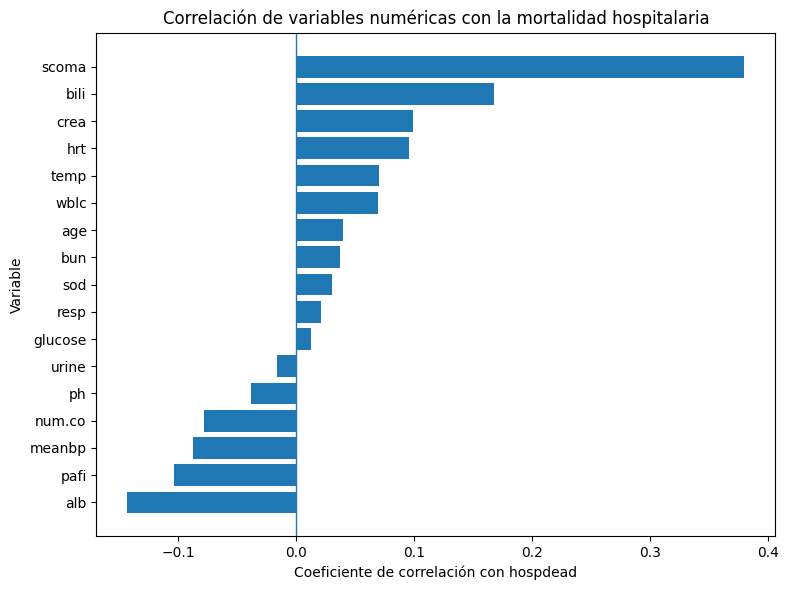

In [104]:
# ============================================================
# 2.6 ANÁLISIS DE CORRELACIÓN CON LA VARIABLE OBJETIVO
# ============================================================

print("=" * 60)
print("2.6 ANÁLISIS DE CORRELACIÓN")
print("=" * 60)

variables_corr = [
    "age",
    "num.co",
    "scoma",
    "meanbp",
    "wblc",
    "hrt",
    "resp",
    "temp",
    "pafi",
    "alb",
    "bili",
    "crea",
    "sod",
    "ph",
    "glucose",
    "bun",
    "urine",
    "hospdead"
]

# Mantener únicamente las variables existentes
variables_corr = [
    col for col in variables_corr
    if col in df_eda.columns
]

# Matriz de correlación
corr = df_eda[variables_corr].corr()

# Correlación de cada variable con hospdead
corr_target = (
    corr["hospdead"]
    .drop("hospdead")
    .sort_values(key=abs, ascending=False)
)

print("\nCorrelación de las variables con hospdead:")
print(corr_target.round(3))


# ============================================================
# GRÁFICO
# ============================================================

# Ordenar para mostrar el gráfico de menor a mayor
corr_plot = corr_target.sort_values()

plt.figure(figsize=(8, 6))

plt.barh(
    corr_plot.index,
    corr_plot.values
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.xlabel("Coeficiente de correlación con hospdead")
plt.ylabel("Variable")

plt.title(
    "Correlación de variables numéricas con la mortalidad hospitalaria"
)

plt.tight_layout()
plt.show()

2.7 MATRIZ DE CORRELACIÓN DE TODAS LAS VARIABLES NUMÉRICAS RESTANTES


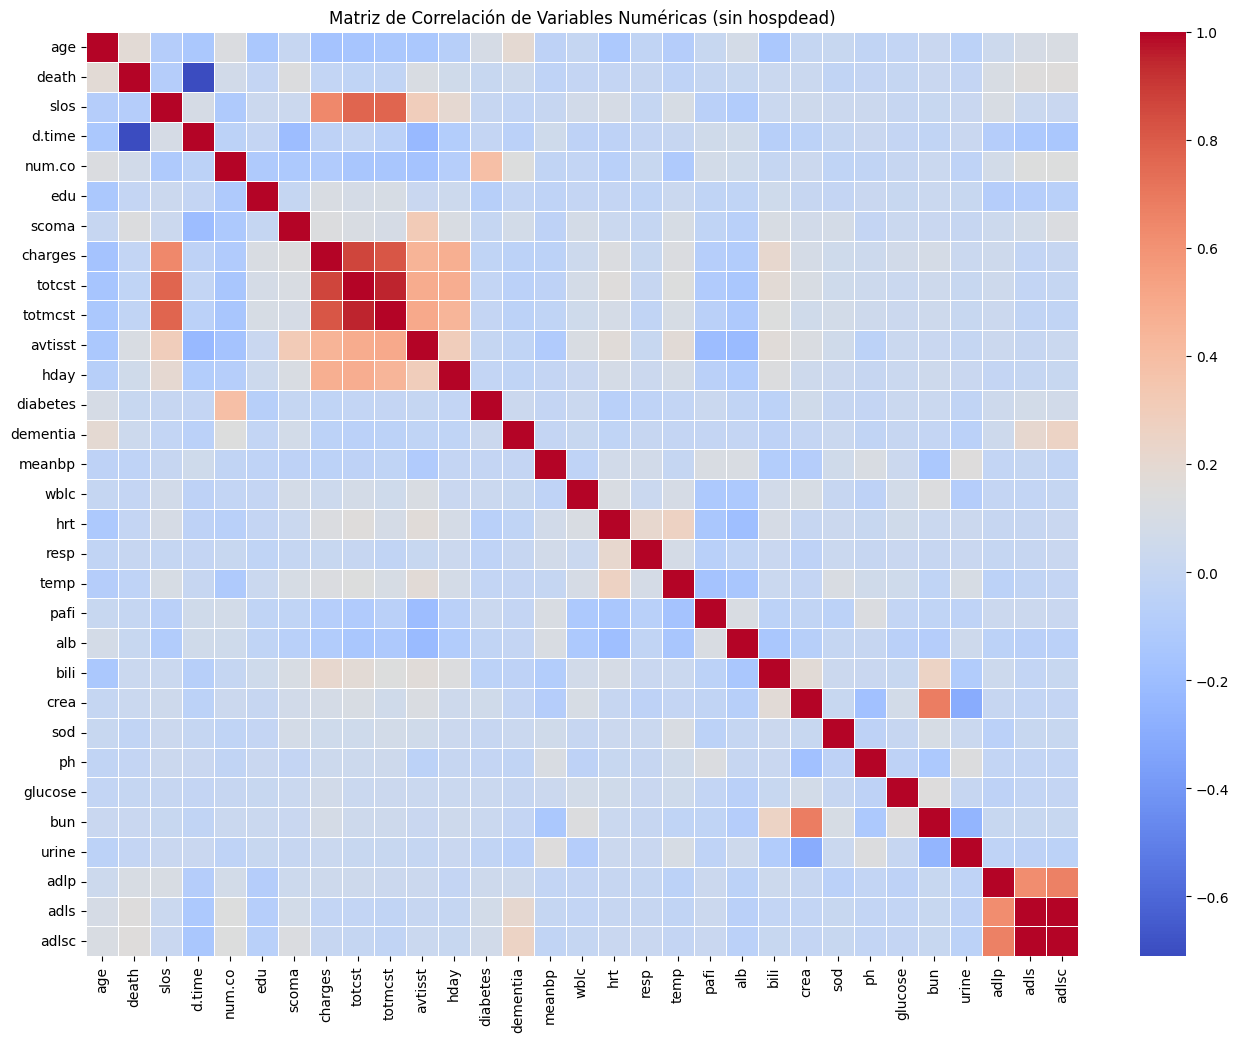

Matriz de Correlación de variables numéricas calculada y visualizada.


In [105]:
# =================================================================================
# 2.7 MATRIZ DE CORRELACIÓN DE TODAS LAS VARIABLES NUMÉRICAS RESTANTES
# Excluye la variable objetivo 'hospdead' de esta matriz de correlación de features
# =================================================================================

print("=" * 60)
print("2.7 MATRIZ DE CORRELACIÓN DE TODAS LAS VARIABLES NUMÉRICAS RESTANTES")
print("=" * 60)
correlation_matrix = df_eda.drop(columns=['hospdead'], errors='ignore').corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas (sin hospdead)')
plt.show()

print("Matriz de Correlación de variables numéricas calculada y visualizada.")

In [106]:
# ============================================================
# 2.8 IDENTIFICACIÓN DE VALORES ATÍPICOS
# MÉTODO DEL RANGO INTERCUARTÍLICO (IQR)
# ============================================================

print("=" * 60)
print("2.8 IDENTIFICACIÓN DE OUTLIERS")
print("=" * 60)

resultados_outliers = []

for col in fisiologicas:

    datos = df_eda[col].dropna()

    # Cuartiles
    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)

    # Rango intercuartílico
    IQR = Q3 - Q1

    # Límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identificar outliers
    outliers = (
        (datos < limite_inferior)
        |
        (datos > limite_superior)
    )

    numero_outliers = outliers.sum()

    porcentaje_outliers = (
        numero_outliers
        / len(datos)
        * 100
    )

    resultados_outliers.append([
        col,
        Q1,
        Q3,
        IQR,
        limite_inferior,
        limite_superior,
        numero_outliers,
        porcentaje_outliers
    ])


outliers_df = pd.DataFrame(
    resultados_outliers,
    columns=[
        "Variable",
        "Q1",
        "Q3",
        "IQR",
        "Límite inferior",
        "Límite superior",
        "N° outliers",
        "Porcentaje (%)"
    ]
)

outliers_df = (
    outliers_df
    .sort_values(
        "Porcentaje (%)",
        ascending=False
    )
)

print("\nOutliers identificados mediante IQR:")
print(outliers_df.round(2))

2.8 IDENTIFICACIÓN DE OUTLIERS

Outliers identificados mediante IQR:
   Variable       Q1       Q3      IQR  Límite inferior  Límite superior  \
7      bili     0.50     1.90     1.40            -1.60             4.00   
8      crea     0.90     1.90     1.00            -0.60             3.40   
11  glucose   103.00   188.00    85.00           -24.50           315.50   
12      bun    14.00    42.00    28.00           -28.00            84.00   
1      wblc     7.00    15.30     8.30            -5.45            27.75   
10       ph     7.38     7.47     0.09             7.25             7.60   
3      resp    18.00    28.00    10.00             3.00            43.00   
9       sod   134.00   141.00     7.00           123.50           151.50   
13    urine  1165.50  3000.00  1834.50         -1586.25          5751.75   
5      pafi   155.09   304.75   149.66           -69.39           529.23   
2       hrt    72.00   120.00    48.00             0.00           192.00   
6       alb     2.4

In [107]:
# ============================================================
# 2.9 RESUMEN GENERAL DEL EDA
# ============================================================

print("=" * 60)
print("2.8 PRINCIPALES RESULTADOS DEL EDA")
print("=" * 60)

# ------------------------------------------------------------
# INFORMACIÓN GENERAL
# ------------------------------------------------------------

print("\n--- DATASET ---")

print(
    "Pacientes:",
    df_raw.shape[0]
)

print(
    "Variables originales:",
    df_raw.shape[1]
)

print(
    "Variables después de excluir leakage:",
    df_eda.shape[1]
)


# ------------------------------------------------------------
# VARIABLE OBJETIVO
# ------------------------------------------------------------

print("\n--- VARIABLE OBJETIVO ---")

print(tabla_clases)


# ------------------------------------------------------------
# MISSING VALUES
# ------------------------------------------------------------

print("\n--- VARIABLES CON MAYOR PORCENTAJE DE MISSING ---")

print(
    missing.head(10)
)


# ------------------------------------------------------------
# CORRELACIÓN CON HOSPDEAD
# ------------------------------------------------------------

print("\n--- MAYOR CORRELACIÓN ABSOLUTA CON HOSPDEAD ---")

print(
    corr_target.head(10)
    .round(3)
)


# ------------------------------------------------------------
# OUTLIERS
# ------------------------------------------------------------

print("\n--- VARIABLES CON MAYOR PORCENTAJE DE OUTLIERS ---")

print(
    outliers_df[
        [
            "Variable",
            "N° outliers",
            "Porcentaje (%)"
        ]
    ]
    .head(10)
    .round(2)
)


print("\nEDA COMPLETADO")

2.8 PRINCIPALES RESULTADOS DEL EDA

--- DATASET ---
Pacientes: 9105
Variables originales: 47
Variables después de excluir leakage: 39

--- VARIABLE OBJETIVO ---
          Frecuencia  Porcentaje (%)
hospdead                            
0               6745           74.08
1               2360           25.92

--- VARIABLES CON MAYOR PORCENTAJE DE MISSING ---
         Faltantes  Porcentaje (%)
adlp          5641           61.95
urine         4862           53.40
glucose       4500           49.42
bun           4352           47.80
totmcst       3475           38.17
alb           3372           37.03
income        2982           32.75
adls          2867           31.49
bili          2601           28.57
pafi          2325           25.54

--- MAYOR CORRELACIÓN ABSOLUTA CON HOSPDEAD ---
scoma     0.380
bili      0.168
alb      -0.143
pafi     -0.104
crea      0.099
hrt       0.095
meanbp   -0.088
num.co   -0.078
temp      0.070
wblc      0.070
Name: hospdead, dtype: float64

--- VARIABLES 

# 3.0 Limpieza y Preparación de Datos Avanzada

### 3.1 Corrección de Tipos de Datos y Manejo de Valores Imposibles

In [108]:
print("=" * 60)
print("3.1 CORRECCIÓN DE TIPOS DE DATOS Y VALORES IMPOSIBLES")
print("=" * 60)

# Convertir 'edu' a tipo numérico, forzando errores a NaN
# Esto es útil si hay valores no numéricos que no se detectaron antes
df_eda['edu'] = pd.to_numeric(df_eda['edu'], errors='coerce')
print("\n'edu' convertido a numérico (errores a NaN).")

# Convertir 'hospdead' a tipo 'category' para un mejor manejo en modelos
df_eda['hospdead'] = df_eda['hospdead'].astype('category')
print("'hospdead' convertido a tipo 'category'.")

# Identificar y reemplazar valores imposibles con NaN
# 'slos' (length of stay) no debería ser negativo
df_eda.loc[df_eda['slos'] < 0, 'slos'] = np.nan
print("'slos' valores negativos convertidos a NaN.")

# 'd.time' (death time) debería ser no negativo, 0 podría indicar muerte al ingreso
# Se asume que valores negativos son errores
df_eda.loc[df_eda['d.time'] < 0, 'd.time'] = np.nan
print("'d.time' valores negativos convertidos a NaN.")

# 'charges', 'totcst', 'totmcst' (costos) no deberían ser negativos
for col in ['charges', 'totcst', 'totmcst']:
    if col in df_eda.columns:
        df_eda.loc[df_eda[col] < 0, col] = np.nan
        print(f"'{col}' valores negativos convertidos a NaN.")

print("\nTipos de datos actualizados para algunas columnas:")
print(df_eda[['edu', 'hospdead', 'slos', 'd.time', 'charges', 'totcst', 'totmcst']].dtypes)

3.1 CORRECCIÓN DE TIPOS DE DATOS Y VALORES IMPOSIBLES

'edu' convertido a numérico (errores a NaN).
'hospdead' convertido a tipo 'category'.
'slos' valores negativos convertidos a NaN.
'd.time' valores negativos convertidos a NaN.
'charges' valores negativos convertidos a NaN.
'totcst' valores negativos convertidos a NaN.
'totmcst' valores negativos convertidos a NaN.

Tipos de datos actualizados para algunas columnas:
edu          float64
hospdead    category
slos         float64
d.time       float64
charges      float64
totcst       float64
totmcst      float64
dtype: object


### 3.2 Estandarización de Categorías

In [109]:
print("=" * 60)
print("3.2 ESTANDARIZACIÓN DE CATEGORÍAS")
print("=" * 60)

# Columnas categóricas a estandarizar
cat_cols_to_standardize = ['sex', 'dzgroup', 'dzclass', 'race', 'income', 'sfdm2']

for col in cat_cols_to_standardize:
    if col in df_eda.columns and df_eda[col].dtype == 'object':
        # Convertir a minúsculas y eliminar espacios en blanco
        df_eda[col] = df_eda[col].str.lower().str.strip()
        print(f"'{col}' estandarizado a minúsculas y sin espacios.")

# Estandarización específica para 'sfdm2' (si es necesario por las categorías observadas)
if 'sfdm2' in df_eda.columns:
    df_eda['sfdm2'] = df_eda['sfdm2'].replace({
        '<2 mo. follow-up': 'less than 2 months follow-up',
        'no(m2 and sip pres)': 'no m2 and sip present'
    })
    print("'sfdm2' categorías estandarizadas.")

print("\nValores únicos después de estandarización para algunas columnas:")
print(df_eda['sex'].value_counts(dropna=False))
print(df_eda['dzgroup'].value_counts(dropna=False))
print(df_eda['income'].value_counts(dropna=False))

3.2 ESTANDARIZACIÓN DE CATEGORÍAS
'sex' estandarizado a minúsculas y sin espacios.
'dzgroup' estandarizado a minúsculas y sin espacios.
'dzclass' estandarizado a minúsculas y sin espacios.
'race' estandarizado a minúsculas y sin espacios.
'income' estandarizado a minúsculas y sin espacios.
'sfdm2' estandarizado a minúsculas y sin espacios.
'sfdm2' categorías estandarizadas.

Valores únicos después de estandarización para algunas columnas:
sex
male      5125
female    3980
Name: count, dtype: int64
dzgroup
arf/mosf w/sepsis    3515
chf                  1387
copd                  967
lung cancer           908
mosf w/malig          712
coma                  596
colon cancer          512
cirrhosis             508
Name: count, dtype: int64
income
NaN           2982
under $11k    2855
$11-$25k      1527
$25-$50k      1057
>$50k          684
Name: count, dtype: int64


### 3.3 Eliminación de Filas Duplicadas

In [110]:
print("=" * 60)
print("3.3 ELIMINACIÓN DE FILAS DUPLICADAS")
print("=" * 60)

initial_rows = df_eda.shape[0]
df_eda.drop_duplicates(inplace=True)
duplicate_rows_removed = initial_rows - df_eda.shape[0]

print(f"Filas duplicadas eliminadas: {duplicate_rows_removed}")
print(f"Dimensiones del DataFrame después de eliminar duplicados: {df_eda.shape}")

3.3 ELIMINACIÓN DE FILAS DUPLICADAS
Filas duplicadas eliminadas: 0
Dimensiones del DataFrame después de eliminar duplicados: (9105, 39)


### 3.4 Manejo de Valores Faltantes (Re-evaluación)

In [111]:
print("=" * 60)
print("3.4 MANEJO DE VALORES FALTANTES (RE-EVALUACIÓN)")
print("=" * 60)

# Re-calcular los valores faltantes después de las limpiezas previas
missing_after_cleaning = pd.DataFrame({
    "Faltantes": df_eda.isnull().sum(),
    "Porcentaje (%)": df_eda.isnull().mean() * 100
}).sort_values("Porcentaje (%)", ascending=False)

missing_after_cleaning = missing_after_cleaning[missing_after_cleaning["Faltantes"] > 0].round(2)
print("\nValores faltantes por variable después de la limpieza:")
print(missing_after_cleaning)

# Volver a aplicar la estrategia de manejo de missing, ajustando si es necesario

# Columnas a eliminar por alto porcentaje de valores faltantes (>50%)
# (adlp, urine, glucose ya deberían estar eliminadas del paso anterior)
# Pero si alguna otra superó el umbral debido a la limpieza, se eliminará aquí

high_missing_cols = missing_after_cleaning[missing_after_cleaning['Porcentaje (%)'] > 50].index.tolist()

# Filtrar las columnas que realmente existen en el df_eda
drop_cols_final = [col for col in high_missing_cols if col in df_eda.columns]

if drop_cols_final:
    df_eda.drop(columns=drop_cols_final, inplace=True)
    print(f"\nColumnas eliminadas debido a un alto porcentaje de valores faltantes (re-evaluación): {drop_cols_final}")
else:
    print("\nNo se eliminaron columnas adicionales por alto porcentaje de valores faltantes.")

# Imputar valores faltantes para variables numéricas con la mediana
# 'bun', 'totmcst', 'alb', 'adls', 'bili', 'pafi' y otras como 'ph', 'edu' (si quedaron con NaNs)
num_cols_to_impute_final = ['bun', 'totmcst', 'alb', 'adls', 'bili', 'pafi', 'ph', 'edu']
for col in num_cols_to_impute_final:
    if col in df_eda.columns and df_eda[col].isnull().any():
        median_val = df_eda[col].median()
        df_eda[col].fillna(median_val, inplace=True)
        print(f"Valores faltantes en '{col}' imputados con la mediana: {median_val}")

# Imputar valores faltantes para la variable categórica 'income' y 'sfdm2' con la moda
cat_cols_to_impute_final = ['income', 'sfdm2']
for col in cat_cols_to_impute_final:
    if col in df_eda.columns and df_eda[col].isnull().any():
        mode_val = df_eda[col].mode()[0]
        df_eda[col].fillna(mode_val, inplace=True)
        print(f"Valores faltantes en '{col}' imputados con la moda: {mode_val}")

print("\nVerificando valores faltantes después de la re-imputación:")
print(df_eda.isnull().sum()[df_eda.isnull().sum() > 0])
print(f"Dimensiones del DataFrame después del manejo final de valores faltantes: {df_eda.shape}")

3.4 MANEJO DE VALORES FALTANTES (RE-EVALUACIÓN)

Valores faltantes por variable después de la limpieza:
         Faltantes  Porcentaje (%)
adlp          5641           61.95
urine         4862           53.40
glucose       4500           49.42
bun           4352           47.80
totmcst       3477           38.19
alb           3372           37.03
income        2982           32.75
adls          2867           31.49
bili          2601           28.57
pafi          2325           25.54
ph            2284           25.09
edu           1634           17.95
sfdm2         1400           15.38
totcst         888            9.75
wblc           212            2.33
charges        172            1.89
avtisst         82            0.90
crea            67            0.74
race            42            0.46
sod              1            0.01
hrt              1            0.01
meanbp           1            0.01
temp             1            0.01
resp             1            0.01
scoma            1   

/tmp/ipykernel_1428/1552870304.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_eda[col].fillna(median_val, inplace=True)
/tmp/ipykernel_1428/1552870304.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

### 3.5 Manejo de Outliers (Re-evaluación)

In [112]:
print("=" * 60)
print("3.5 MANEJO DE OUTLIERS (RE-EVALUACIÓN)")
print("=" * 60)

# Re-identificar outliers después de la limpieza y manejo de NaNs
resultados_outliers_re_eval = []

# Seleccionar solo columnas numéricas para la detección de outliers
num_cols_for_outliers = df_eda.select_dtypes(include=np.number).columns.tolist()

for col in num_cols_for_outliers:
    datos = df_eda[col].dropna()
    if datos.empty: # Evitar errores si la columna está completamente vacía
        continue

    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = ((datos < limite_inferior) | (datos > limite_superior))
    numero_outliers = outliers.sum()

    if len(datos) > 0:
        porcentaje_outliers = (numero_outliers / len(datos)) * 100
    else:
        porcentaje_outliers = 0

    resultados_outliers_re_eval.append([
        col,
        Q1,
        Q3,
        IQR,
        limite_inferior,
        limite_superior,
        numero_outliers,
        porcentaje_outliers
    ])

outliers_df_re_eval = pd.DataFrame(
    resultados_outliers_re_eval,
    columns=[
        "Variable", "Q1", "Q3", "IQR",
        "Límite inferior", "Límite superior",
        "N° outliers", "Porcentaje (%)"
    ]
).sort_values("Porcentaje (%)", ascending=False)

print("\nOutliers identificados mediante IQR (re-evaluación):")
print(outliers_df_re_eval.round(2))

# Visualización de algunos outliers seleccionados (opcional)


3.5 MANEJO DE OUTLIERS (RE-EVALUACIÓN)

Outliers identificados mediante IQR (re-evaluación):
    Variable       Q1        Q3       IQR  Límite inferior  Límite superior  \
26       bun    22.00     24.00      2.00            19.00            27.00   
5        edu    11.00     12.00      1.00             9.50            13.50   
20       alb     2.70      3.10      0.40             2.10             3.70   
6      scoma     0.00      9.00      9.00           -13.50            22.50   
12  diabetes     0.00      0.00      0.00             0.00             0.00   
27      adls     0.00      1.00      1.00            -1.50             2.50   
11      hday     1.00      3.00      2.00            -2.00             6.00   
9    totmcst  9371.73  19144.83   9773.10         -5287.93         33804.48   
21      bili     0.60      1.30      0.70            -0.45             2.35   
24        ph     7.40      7.45      0.05             7.32             7.52   
22      crea     0.90      1.90      1

# 4.0 Análisis Bivariado

### 4.1 Variables Categóricas vs. Hospdead

4.1 VARIABLES CATEGÓRICAS VS. HOSPDEAD


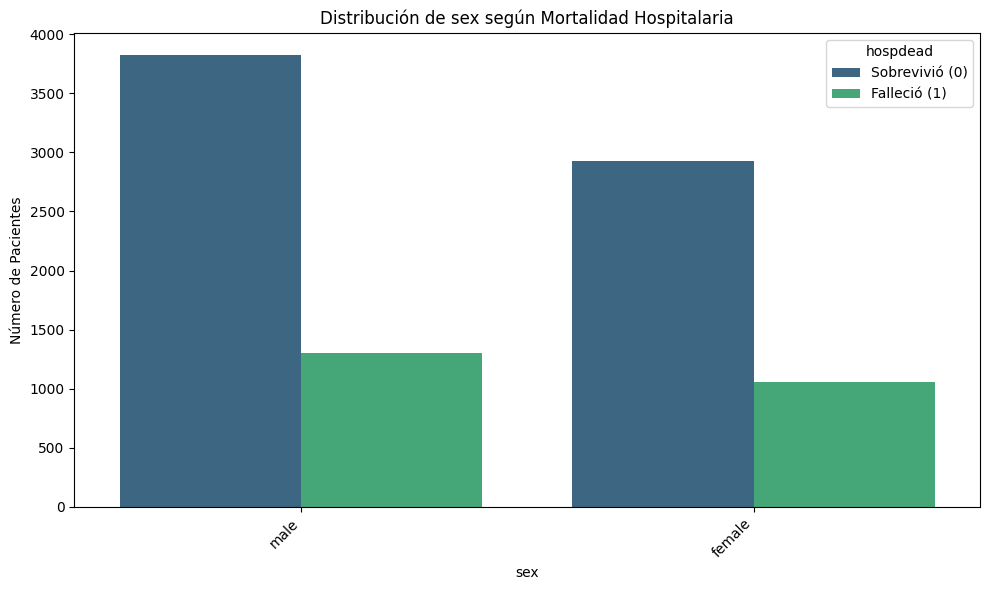


Prueba Chi-cuadrado para sex vs hospdead:
  Chi2: 1.22
  P-valor: 0.270
  No hay una relación significativa entre sex y hospdead (p >= 0.05).
------------------------------


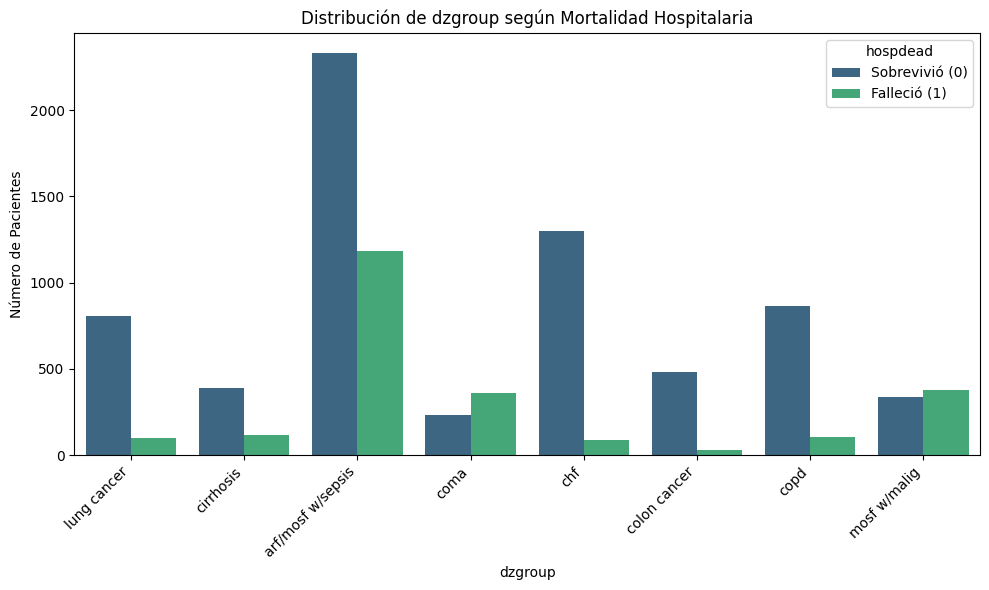


Prueba Chi-cuadrado para dzgroup vs hospdead:
  Chi2: 1361.52
  P-valor: 0.000
  Existe una relación significativa entre dzgroup y hospdead (p < 0.05).
------------------------------


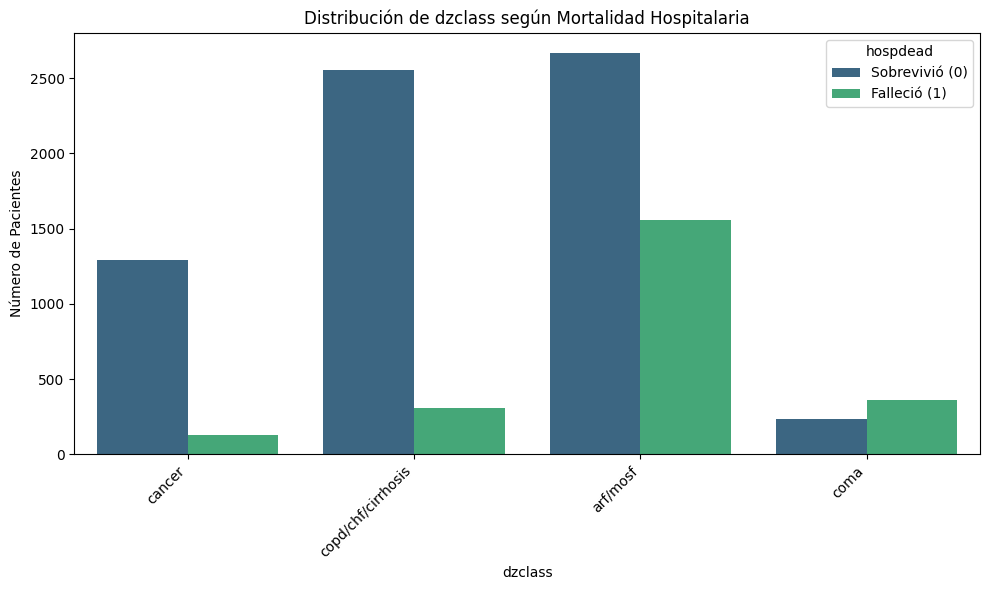


Prueba Chi-cuadrado para dzclass vs hospdead:
  Chi2: 1189.42
  P-valor: 0.000
  Existe una relación significativa entre dzclass y hospdead (p < 0.05).
------------------------------


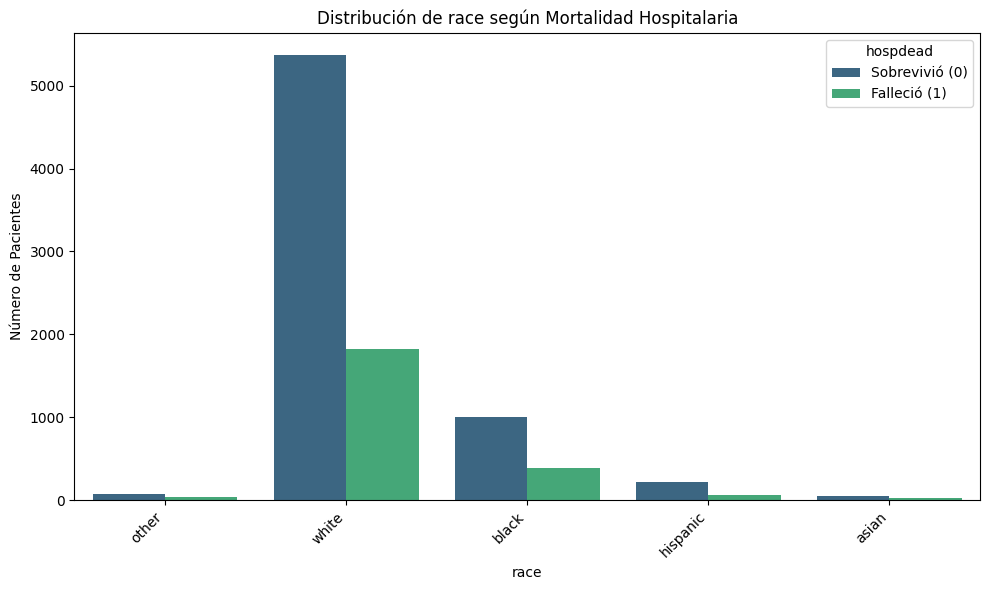


Prueba Chi-cuadrado para race vs hospdead:
  Chi2: 12.95
  P-valor: 0.012
  Existe una relación significativa entre race y hospdead (p < 0.05).
------------------------------


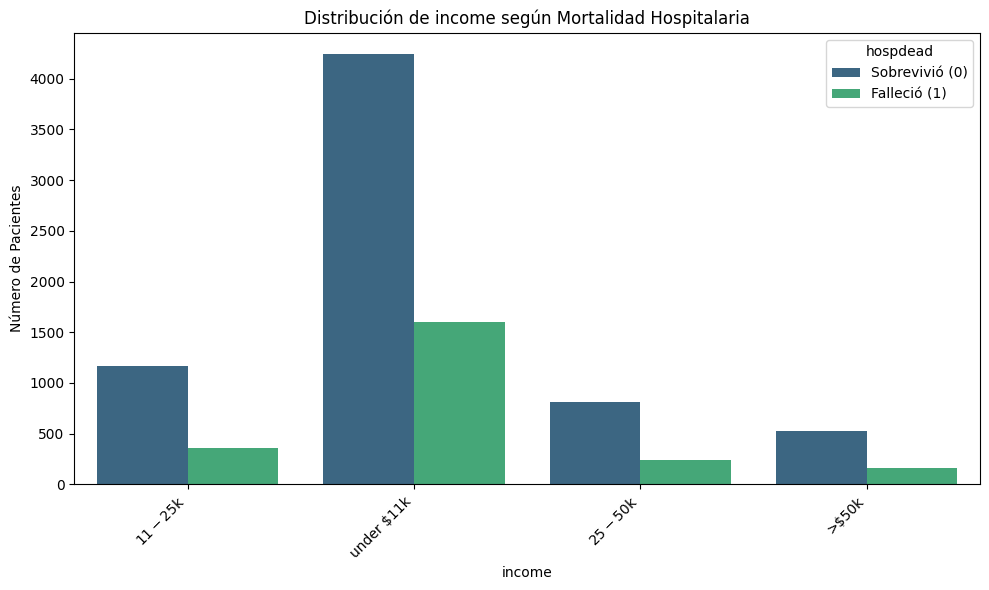


Prueba Chi-cuadrado para income vs hospdead:
  Chi2: 18.14
  P-valor: 0.000
  Existe una relación significativa entre income y hospdead (p < 0.05).
------------------------------


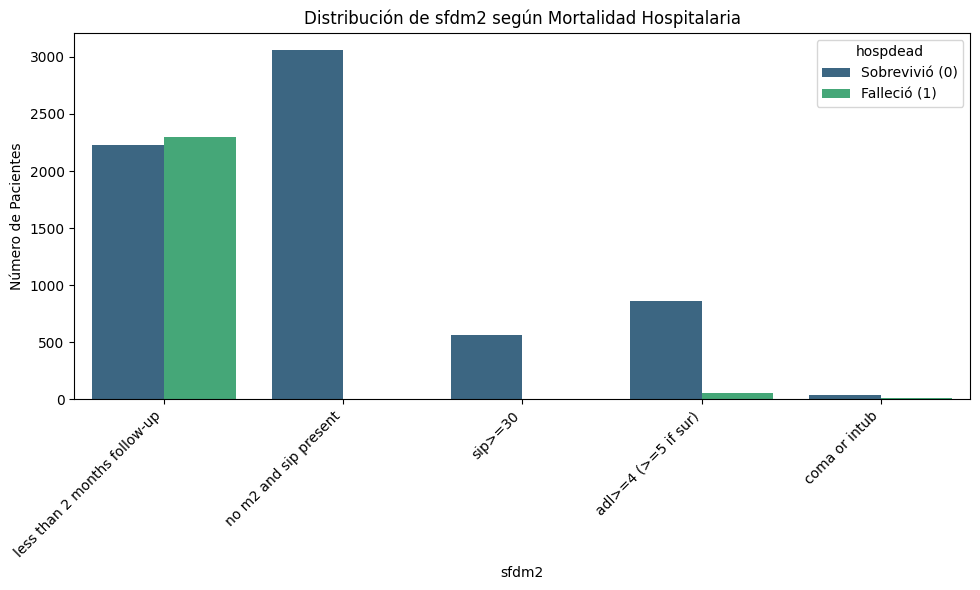


Prueba Chi-cuadrado para sfdm2 vs hospdead:
  Chi2: 2895.38
  P-valor: 0.000
  Existe una relación significativa entre sfdm2 y hospdead (p < 0.05).
------------------------------


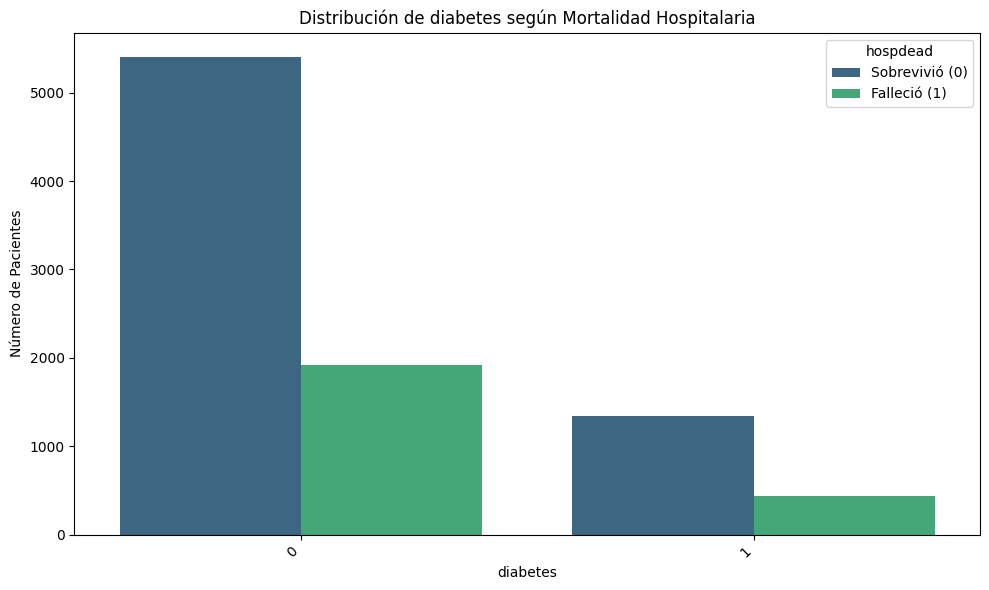


Prueba Chi-cuadrado para diabetes vs hospdead:
  Chi2: 1.51
  P-valor: 0.219
  No hay una relación significativa entre diabetes y hospdead (p >= 0.05).
------------------------------


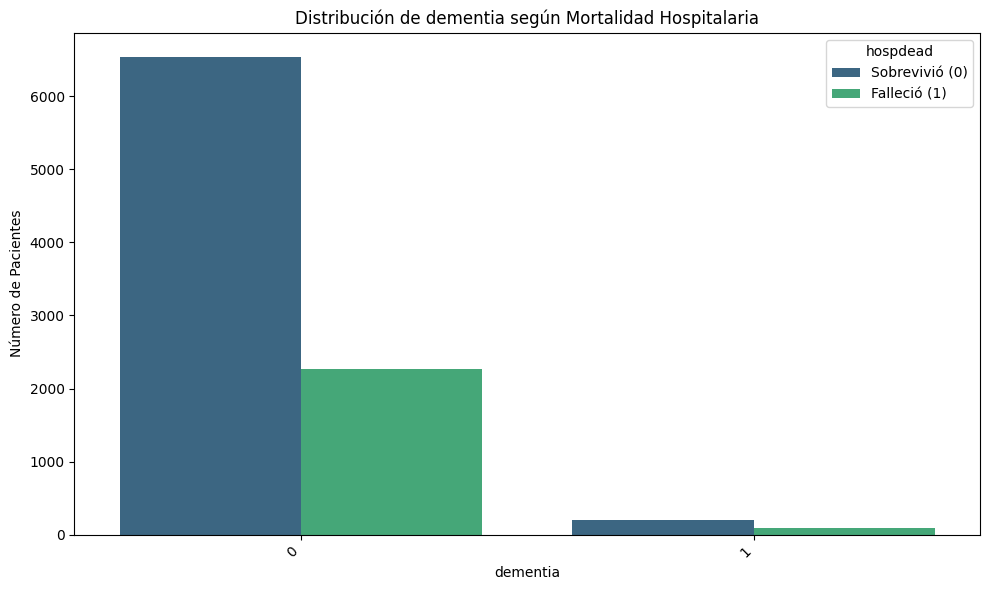


Prueba Chi-cuadrado para dementia vs hospdead:
  Chi2: 5.75
  P-valor: 0.017
  Existe una relación significativa entre dementia y hospdead (p < 0.05).
------------------------------


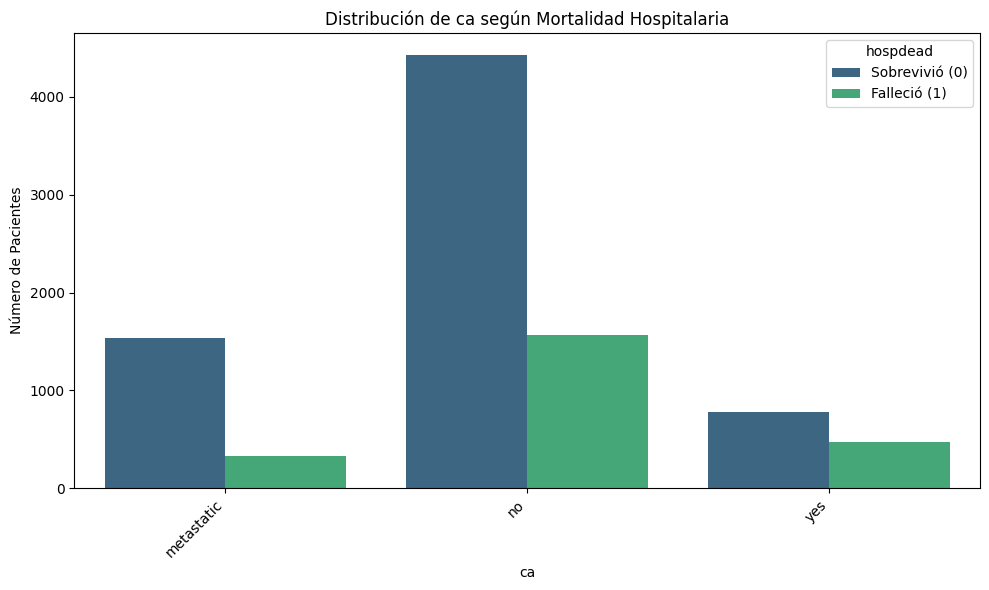


Prueba Chi-cuadrado para ca vs hospdead:
  Chi2: 155.10
  P-valor: 0.000
  Existe una relación significativa entre ca y hospdead (p < 0.05).
------------------------------


In [113]:
print("=" * 60)
print("4.1 VARIABLES CATEGÓRICAS VS. HOSPDEAD")
print("=" * 60)

cat_features = [
    'sex', 'dzgroup', 'dzclass', 'race', 'income', 'sfdm2',
    'diabetes', 'dementia', 'ca' # Estas son binarias/categóricas también
]

# Filtrar solo las que existen en df_eda
cat_features = [col for col in cat_features if col in df_eda.columns]

for feature in cat_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_eda, x=feature, hue='hospdead', palette='viridis')
    plt.title(f'Distribución de {feature} según Mortalidad Hospitalaria')
    plt.xlabel(feature)
    plt.ylabel('Número de Pacientes')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='hospdead', labels=['Sobrevivió (0)', 'Falleció (1)'])
    plt.tight_layout()
    plt.show()

    # Prueba Chi-cuadrado para independencia (si la variable tiene más de 1 categoría)
    if df_eda[feature].nunique() > 1:
        contingency_table = pd.crosstab(df_eda[feature], df_eda['hospdead'])
        from scipy.stats import chi2_contingency
        chi2, p_value, _, _ = chi2_contingency(contingency_table)
        print(f"\nPrueba Chi-cuadrado para {feature} vs hospdead:")
        print(f"  Chi2: {chi2:.2f}")
        print(f"  P-valor: {p_value:.3f}")
        if p_value < 0.05:
            print(f"  Existe una relación significativa entre {feature} y hospdead (p < 0.05).")
        else:
            print(f"  No hay una relación significativa entre {feature} y hospdead (p >= 0.05).")
    print("-" * 30)


### 4.2 Variables Numéricas vs. Hospdead

4.2 VARIABLES NUMÉRICAS VS. HOSPDEAD

Top 8 características numéricas con mayor correlación absoluta con 'hospdead': ['avtisst', 'd.time', 'death', 'scoma', 'hday', 'totcst', 'charges', 'bili']


/tmp/ipykernel_1428/778246109.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='hospdead', y=feature, palette='coolwarm')


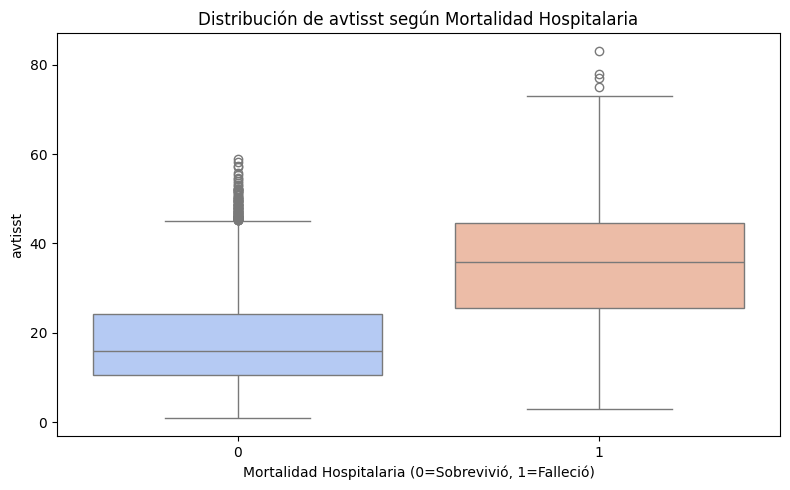


Prueba t de Student para avtisst vs hospdead:
  Estadístico t: -62.96
  P-valor: 0.000
  Existe una diferencia significativa en la media de avtisst entre los grupos de hospdead (p < 0.05).
------------------------------


/tmp/ipykernel_1428/778246109.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='hospdead', y=feature, palette='coolwarm')


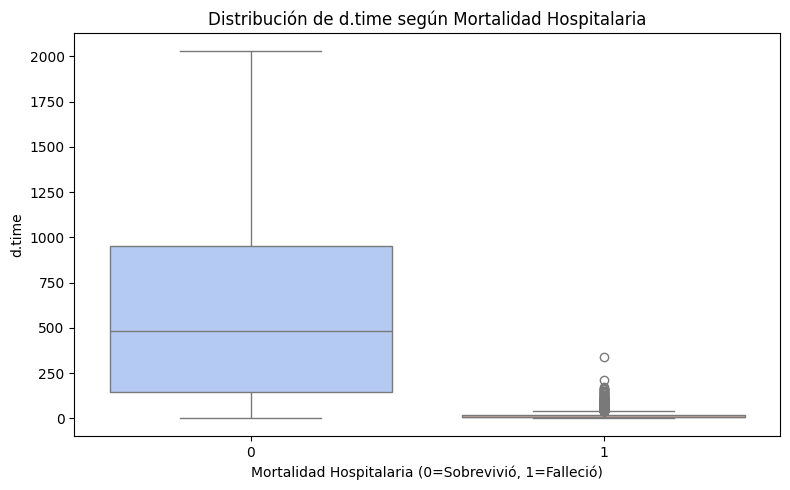


Prueba t de Student para d.time vs hospdead:
  Estadístico t: 53.14
  P-valor: 0.000
  Existe una diferencia significativa en la media de d.time entre los grupos de hospdead (p < 0.05).
------------------------------


/tmp/ipykernel_1428/778246109.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='hospdead', y=feature, palette='coolwarm')


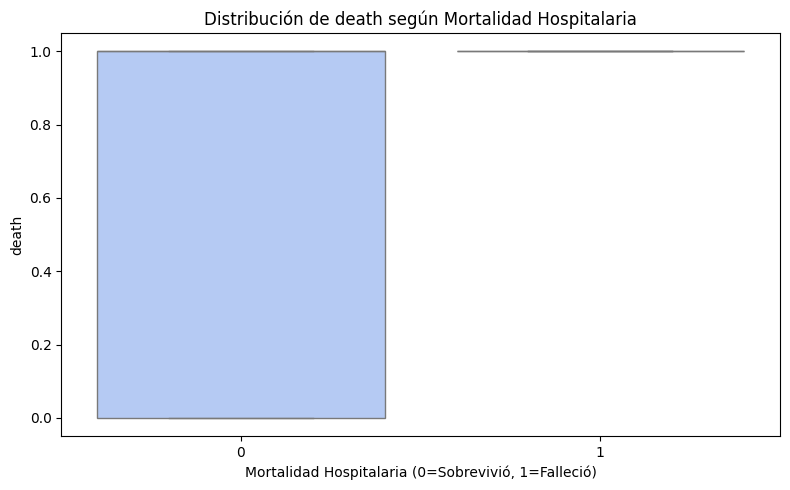

/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/tmp/ipykernel_1428/778246109.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='hospdead', y=feature, palette='coolwarm')



Prueba t de Student para death vs hospdead:
  Estadístico t: -42.24
  P-valor: 0.000
  Existe una diferencia significativa en la media de death entre los grupos de hospdead (p < 0.05).
------------------------------


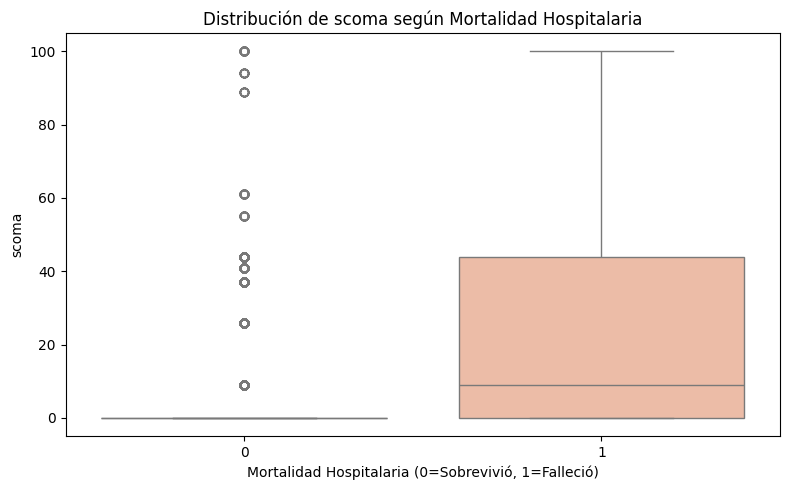


Prueba t de Student para scoma vs hospdead:
  Estadístico t: -39.14
  P-valor: 0.000
  Existe una diferencia significativa en la media de scoma entre los grupos de hospdead (p < 0.05).
------------------------------


/tmp/ipykernel_1428/778246109.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='hospdead', y=feature, palette='coolwarm')


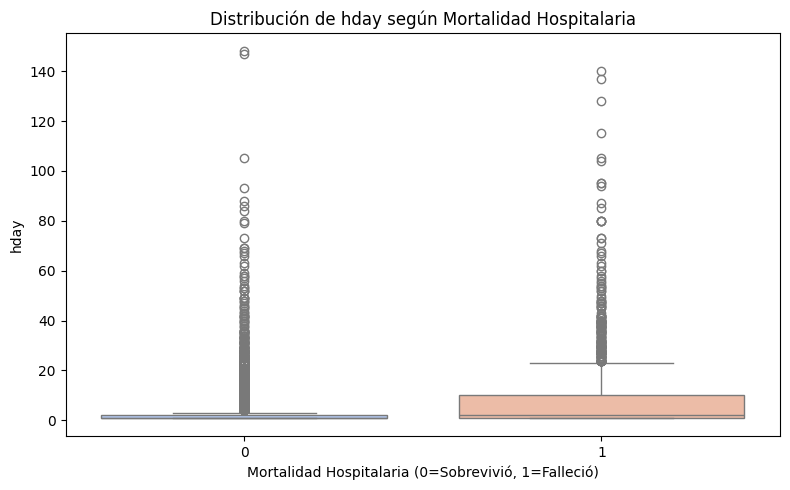


Prueba t de Student para hday vs hospdead:
  Estadístico t: -20.88
  P-valor: 0.000
  Existe una diferencia significativa en la media de hday entre los grupos de hospdead (p < 0.05).
------------------------------


/tmp/ipykernel_1428/778246109.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='hospdead', y=feature, palette='coolwarm')


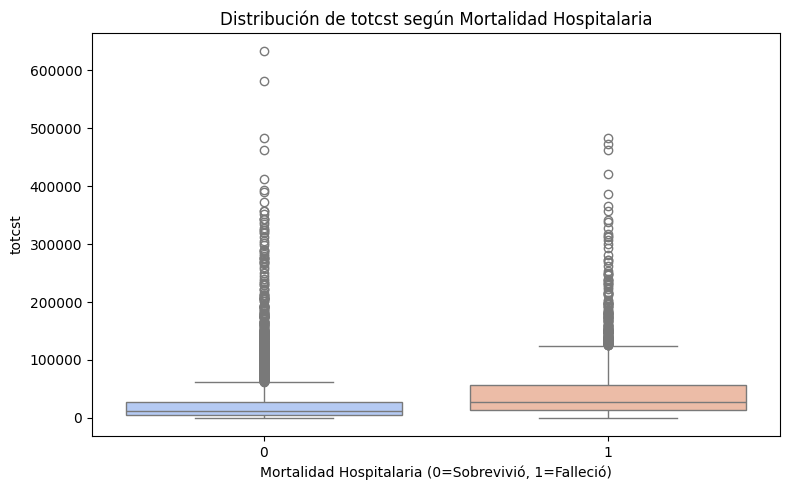


Prueba t de Student para totcst vs hospdead:
  Estadístico t: -17.71
  P-valor: 0.000
  Existe una diferencia significativa en la media de totcst entre los grupos de hospdead (p < 0.05).
------------------------------


/tmp/ipykernel_1428/778246109.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='hospdead', y=feature, palette='coolwarm')


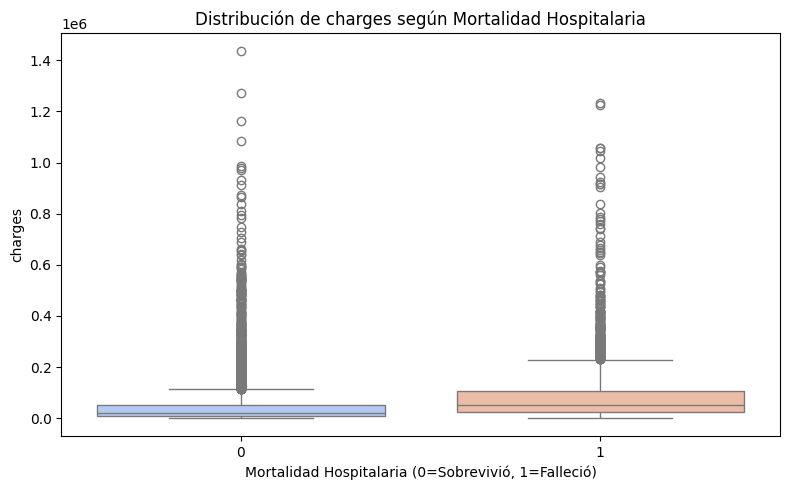


Prueba t de Student para charges vs hospdead:
  Estadístico t: -18.01
  P-valor: 0.000
  Existe una diferencia significativa en la media de charges entre los grupos de hospdead (p < 0.05).
------------------------------


/tmp/ipykernel_1428/778246109.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='hospdead', y=feature, palette='coolwarm')


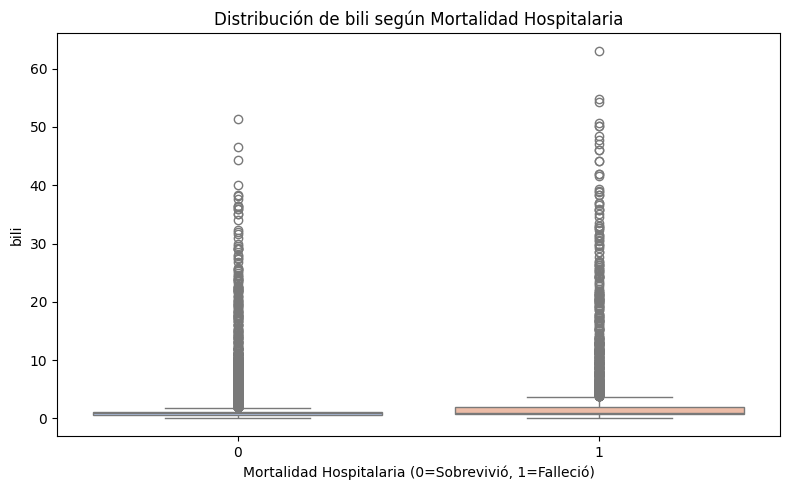


Prueba t de Student para bili vs hospdead:
  Estadístico t: -13.95
  P-valor: 0.000
  Existe una diferencia significativa en la media de bili entre los grupos de hospdead (p < 0.05).
------------------------------


In [114]:
print("=" * 60)
print("4.2 VARIABLES NUMÉRICAS VS. HOSPDEAD")
print("=" * 60)

# Re-calcular correlación con hospdead para el df_eda limpio
# Crear una copia de df_eda y convertir 'hospdead' a tipo numérico (int) para el cálculo de correlación
df_eda_numeric_for_corr = df_eda.copy()
df_eda_numeric_for_corr['hospdead'] = df_eda_numeric_for_corr['hospdead'].astype(int)

# Ahora calcular la correlación con todas las variables numéricas, incluyendo la versión numérica de 'hospdead'
corr_target_cleaned = df_eda_numeric_for_corr.corr(numeric_only=True)['hospdead'].drop('hospdead', errors='ignore')
top_num_features = corr_target_cleaned.abs().sort_values(ascending=False).head(8).index.tolist()

print(f"\nTop 8 características numéricas con mayor correlación absoluta con 'hospdead': {top_num_features}")

for feature in top_num_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_eda, x='hospdead', y=feature, palette='coolwarm')
    plt.title(f'Distribución de {feature} según Mortalidad Hospitalaria')
    plt.xlabel('Mortalidad Hospitalaria (0=Sobrevivió, 1=Falleció)')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

    # Realizar prueba t de Student para comparar medias (o Mann-Whitney U si no es normal/tamaño pequeño)
    # Asumiremos normalidad para fines de ejemplo, pero se debería verificar.
    from scipy.stats import ttest_ind

    # Filtrar datos para los dos grupos de hospdead
    group0 = df_eda[df_eda['hospdead'] == 0][feature].dropna()
    group1 = df_eda[df_eda['hospdead'] == 1][feature].dropna()

    if not group0.empty and not group1.empty:
        t_stat, p_value = ttest_ind(group0, group1)
        print(f"\nPrueba t de Student para {feature} vs hospdead:")
        print(f"  Estadístico t: {t_stat:.2f}")
        print(f"  P-valor: {p_value:.3f}")
        if p_value < 0.05:
            print(f"  Existe una diferencia significativa en la media de {feature} entre los grupos de hospdead (p < 0.05).")
        else:
            print(f"  No hay una diferencia significativa en la media de {feature} entre los grupos de hospdead (p >= 0.05).")
    else:
        print(f"\nNo hay suficientes datos para realizar la prueba t de Student para {feature}.")
    print("-" * 30)

### 4.2.1 Mapa de Calor de Correlación (Características Numéricas Principales vs. Hospdead)

Para obtener una visión general de las correlaciones entre las características numéricas más relevantes y la variable objetivo `hospdead` (representada como 0 y 1), generamos un mapa de calor. Esto nos permite identificar rápidamente las relaciones lineales positivas y negativas, así como la fuerza de estas relaciones.

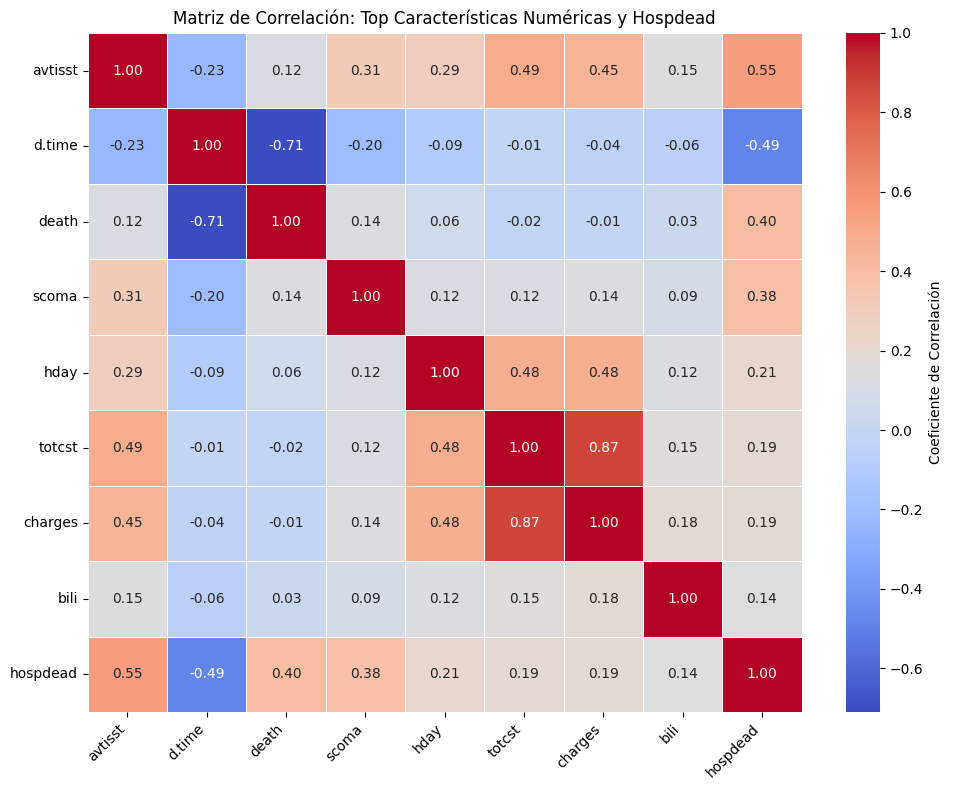

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

features_for_heatmap = top_num_features + ['hospdead']

# Calcular la matriz de correlación para estas características
# Usamos df_eda_numeric_for_corr que ya tiene 'hospdead' como int.
corr_matrix_subset = df_eda_numeric_for_corr[features_for_heatmap].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix_subset,
    annot=True, # Mostrar los valores de correlación en el mapa de calor
    cmap='coolwarm', # Elegir un mapa de color divergente
    fmt=".2f", # Formato de dos decimales para las anotaciones
    linewidths=.5, # Líneas entre las celdas
    cbar_kws={'label': 'Coeficiente de Correlación'}
)
plt.title('Matriz de Correlación: Top Características Numéricas y Hospdead')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()